In [2]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
DENORM_DIR   = r"Optiver\individual_book_train_denorm"
OUTPUT_PATH  = r"Optiver\model_ready.parquet"

# ── constants ──────────────────────────────────────────────────────────────
OBS_SECONDS  = 480   # 8 minutes observation window
TARGET_START = 480   # last 120 seconds for target RV

In [3]:
def compute_rv(log_returns):
    """Realised volatility = sqrt(sum of squared log returns)"""
    return np.sqrt(np.sum(log_returns ** 2))

def compute_features(df_obs, df_target, stock_id, time_id):
    """
    df_obs    — first 480 seconds of a session
    df_target — last 120 seconds of a session
    Returns a single-row dict of features + target
    """
    # log returns from WAP
    log_ret = np.log(df_obs['wap']).diff().dropna()

    # target RV from last 120 seconds
    log_ret_target = np.log(df_target['wap']).diff().dropna()
    target_rv = compute_rv(log_ret_target)

    return {
        # identifiers
        'stock_id'              : stock_id,
        'time_id'               : time_id,
    
        # RV at multiple horizons — core predictors
        'rv_2min'               : compute_rv(log_ret.iloc[:119]),
        'rv_5min'               : compute_rv(log_ret.iloc[:299]),
        'rv_8min'               : compute_rv(log_ret),
    
        # return distribution — skew/kurt noisy but kept for RQ2 analysis
        'log_ret_std'           : log_ret.std(),
        'log_ret_skew'          : log_ret.skew(),
        'log_ret_kurt'          : log_ret.kurt(),
    
        # spread — liquidity signal
        'mean_spread'           : df_obs['bid_ask_spread'].mean(),
        'max_spread'            : df_obs['bid_ask_spread'].max(),
    
        # volume — order flow
        'mean_volume'           : df_obs['total_volume'].mean(),
        'signed_volume'         : (np.sign(log_ret) * df_obs['total_volume'].iloc[1:]).sum(),
    
        # depth imbalance — microstructure
        'mean_depth_imbalance'  : df_obs['depth_imbalance'].mean(),
        'std_depth_imbalance'   : df_obs['depth_imbalance'].std(),
    
        # target
        'target_rv'             : target_rv,
    }


def process_stock(path):
    stock_id = int(os.path.basename(path).split('_')[1].split('.')[0])
    try: 
        df = pd.read_csv(path)
        
        # split into obs and target in one go
        df_obs    = df[df['seconds_in_bucket'] < OBS_SECONDS].copy()
        df_target = df[df['seconds_in_bucket'] >= TARGET_START].copy()
        
        # log returns vectorised across all time_ids at once
        df_obs['log_wap']    = np.log(df_obs['wap'])
        df_target['log_wap'] = np.log(df_target['wap'])
        
        # log returns per time_id
        df_obs['log_ret']    = df_obs.groupby('time_id')['log_wap'].diff()
        df_target['log_ret'] = df_target.groupby('time_id')['log_wap'].diff()
        
        # ── target RV ────────────────────────────────────────────────────────
        target_rv = (df_target.groupby('time_id')['log_ret']
                              .apply(lambda x: np.sqrt(np.sum(x**2)))
                              .rename('target_rv'))
    
        # ── RV at multiple horizons ───────────────────────────────────────────
        obs_2min = df_obs[df_obs['seconds_in_bucket'] < 120]
        obs_5min = df_obs[df_obs['seconds_in_bucket'] < 300]
    
        rv_2min = (obs_2min.groupby('time_id')['log_ret']
                           .apply(lambda x: np.sqrt(np.sum(x**2)))
                           .rename('rv_2min'))
        rv_5min = (obs_5min.groupby('time_id')['log_ret']
                           .apply(lambda x: np.sqrt(np.sum(x**2)))
                           .rename('rv_5min'))
        rv_8min = (df_obs.groupby('time_id')['log_ret']
                         .apply(lambda x: np.sqrt(np.sum(x**2)))
                         .rename('rv_8min'))
    
        # ── return distribution ───────────────────────────────────────────────
        log_ret_std  = df_obs.groupby('time_id')['log_ret'].std().rename('log_ret_std')
        log_ret_skew = df_obs.groupby('time_id')['log_ret'].skew().rename('log_ret_skew')
        log_ret_kurt = (df_obs.groupby('time_id')['log_ret']
                              .apply(lambda x: x.kurt())
                              .rename('log_ret_kurt'))
    
        # ── spread ────────────────────────────────────────────────────────────
        mean_spread = df_obs.groupby('time_id')['bid_ask_spread'].mean().rename('mean_spread')
        max_spread  = df_obs.groupby('time_id')['bid_ask_spread'].max().rename('max_spread')
    
        # ── volume ────────────────────────────────────────────────────────────
        mean_volume = df_obs.groupby('time_id')['total_volume'].mean().rename('mean_volume')
    
        # signed volume — volume weighted by return sign
        df_obs['signed_vol'] = np.sign(df_obs['log_ret']) * df_obs['total_volume']
        signed_volume = df_obs.groupby('time_id')['signed_vol'].sum().rename('signed_volume')
    
        # ── depth imbalance ───────────────────────────────────────────────────
        mean_depth = df_obs.groupby('time_id')['depth_imbalance'].mean().rename('mean_depth_imbalance')
        std_depth  = df_obs.groupby('time_id')['depth_imbalance'].std().rename('std_depth_imbalance')
    
        # ── combine ───────────────────────────────────────────────────────────
        features = pd.concat([
            rv_2min, rv_5min, rv_8min,
            log_ret_std, log_ret_skew, log_ret_kurt,
            mean_spread, max_spread,
            mean_volume, signed_volume,
            mean_depth, std_depth,
            target_rv
        ], axis=1).reset_index()
    
        features['stock_id'] = stock_id
        return features
    except Exception as e:
        print(f"Failed on stock_{stock_id}: {e}")
        return pd.DataFrame()  # return empty df so concat doesn't break

# ── run across all 112 stocks ───────────────────────────────────────────────
# debug single stock first
# test_path = files[0]
# result = process_stock(test_path)
# print(result.shape)
# print(result.head())

files = glob.glob(os.path.join(DENORM_DIR, "stock_*.csv"))
print(f"Processing {len(files)} stocks...")


from joblib import Parallel, delayed
dfs = Parallel(n_jobs=-1, verbose=5)(
    delayed(process_stock)(p) for p in files
)

model_ready = pd.concat(dfs, ignore_index=True)
model_ready.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved model_ready.parquet — shape: {model_ready.shape}")
print(model_ready.head())
print(model_ready.describe())

Processing 112 stocks...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   52.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 112 out of 112 | elapsed:  7.0min finished


Saved model_ready.parquet — shape: (428932, 15)
   time_id   rv_2min   rv_5min   rv_8min  log_ret_std  log_ret_skew  \
0        5  0.002011  0.003394  0.004253     0.000194      0.617214   
1       11  0.000516  0.000699  0.000805     0.000037     -0.443238   
2       16  0.000865  0.001983  0.002238     0.000102     -0.435224   
3       31  0.000976  0.001863  0.002377     0.000109     -4.311481   
4       62  0.000987  0.001131  0.001502     0.000069     -3.214790   

   log_ret_kurt  mean_spread  max_spread  mean_volume  signed_volume  \
0      7.228784     0.000881    0.001394   329.929167          304.0   
1     24.953007     0.000446    0.000904   386.702083         5731.0   
2     25.653374     0.000770    0.001150   416.106250        -3323.0   
3     65.290716     0.000862    0.001624   426.622917        -2810.0   
4     44.716775     0.000385    0.000793   323.875000         1143.0   

   mean_depth_imbalance  std_depth_imbalance  target_rv  stock_id  
0             -0.053751 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


model_ready = pd.read_parquet(r"Optiver\model_ready.parquet")

# aggregate each feature to a single value per stock
# median is more robust than mean given the extreme kurtosis values we saw
stock_stats = (
    model_ready
    .groupby('stock_id')
    .agg(
        rv_8min_med        = ('rv_8min',               'median'),
        rv_8min_std        = ('rv_8min',               'std'),
        log_ret_std_med    = ('log_ret_std',            'median'),
        log_ret_skew_med   = ('log_ret_skew',           'median'),
        log_ret_kurt_med   = ('log_ret_kurt',           'median'),
        mean_spread_med    = ('mean_spread',            'median'),
        max_spread_med     = ('max_spread',             'median'),
        mean_volume_med    = ('mean_volume',            'median'),
        signed_volume_med  = ('signed_volume',          'median'),
        depth_imbal_med    = ('mean_depth_imbalance',   'median'),
        depth_imbal_std    = ('std_depth_imbalance',    'median'),
        target_rv_med      = ('target_rv',              'median'),
    )
    .reset_index()
)

print(f"Stock summary stats shape: {stock_stats.shape}")
print(stock_stats.head())

Stock summary stats shape: (112, 13)
   stock_id  rv_8min_med  rv_8min_std  log_ret_std_med  log_ret_skew_med  \
0         0     0.002972     0.003436         0.000136         -0.046140   
1         1     0.003450     0.003014         0.000158         -0.011817   
2         2     0.001597     0.002623         0.000073         -0.036193   
3         3     0.005085     0.004060         0.000232         -0.038750   
4         4     0.003111     0.003555         0.000142          0.049622   

   log_ret_kurt_med  mean_spread_med  max_spread_med  mean_volume_med  \
0         17.621670         0.000740        0.001372       375.564583   
1          7.914528         0.000579        0.001110       540.217708   
2          5.612712         0.000172        0.000386       758.542708   
3         10.333586         0.000896        0.001943       483.386458   
4         15.057318         0.000689        0.001298       348.306250   

   signed_volume_med  depth_imbal_med  depth_imbal_std  target_rv_m

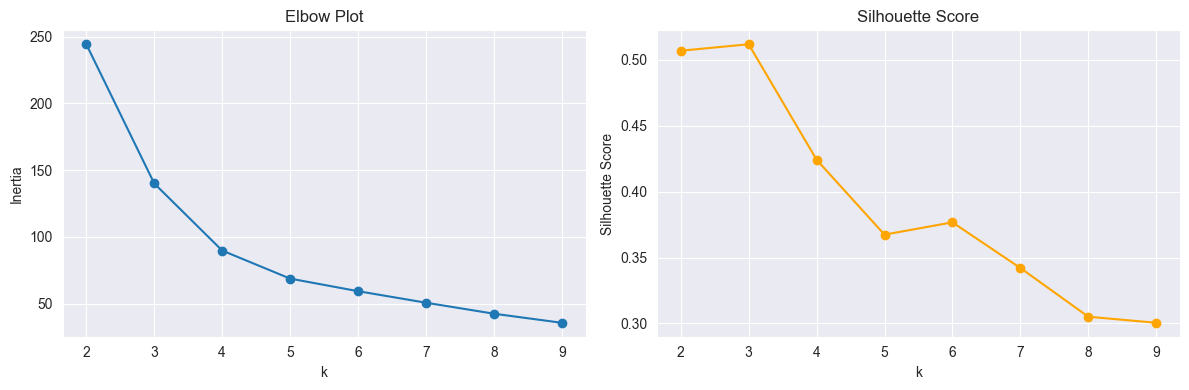

In [8]:
# ── scale ────────────────────────────────────────────────────────────────────
# feature_cols = [c for c in stock_stats.columns if c != 'stock_id']
# X = stock_stats[feature_cols].values
cluster_features = ['rv_8min_med', 'rv_8min_std', 'mean_spread_med', 'mean_volume_med']
X = stock_stats[cluster_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── elbow + silhouette ───────────────────────────────────────────────────────
inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')

axes[1].plot(K_range, silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()